# Question 4

In [1]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter, defaultdict

### Code to create a Gilbert random graph corresponding to an undirected and unweighted real-world network.

##### Gilbert Random Graph G(N, p)

We generate a random graph corresponding to the real-world network
using the Gilbert model G(N, p).

    N = number of nodes in the real network
    L = number of edges in the real network

The connection probability is computed as:

    p = (2L) / (N(N - 1))

In the Gilbert model, each pair of nodes is connected independently
with probability p.


In [2]:
"""
This function generates a graph G(N, p) 
where N is the number of nodes and p is the probability of edge creation between any two nodes.
"""

def generate_gilbert_random_graph(N, p):
    
    # adjacency list representation of the graph
    adj_list = {i: set() for i in range(N)}

    # Iterate through all possible pairs (i, j) where i < j
    for i in range(N):
        for j in range(i + 1, N):
            if random.random() < p:
                adj_list[i].add(j)
                adj_list[j].add(i)

    return adj_list

---

### Extracting N and L from the real graph, and computing the probability

In [3]:
"""
Extracting N and L from the real graph, and computing the probability
"""

# File path to the Facebook friends list data
filename = "Facebook_Friends_List_Data.txt"

# Reading the dataset and extracting edges and unique nodes
edge_list = []
nodes_set = set()
with open("Facebook_Friends_List_Data.txt", "r") as f:
    for line in f:
        nodes = line.strip().split()
        u, v = map(int, nodes)
        edge_list.append((u, v))
        nodes_set.add(u)
        nodes_set.add(v)
        
# Computing N and L from the dataset
N = len(nodes_set)      # number of unique nodes
L = len(edge_list)      # number of edges (undirected)

# Computing p for creating a Gilbert random graph with the same N and L
p = (2 * L) / (N * (N - 1))

print("Number of nodes (N):", N)
print("Number of edges (L):", L)
print("Probability (p):", p)

Number of nodes (N): 4039
Number of edges (L): 88234
Probability (p): 0.010819963503439287


---

### Plot and compare the ‘degree distributions’ of Real Graph and Gilbert Random Graph.

In [4]:
"""
This function computes the degree distribution P(k) for a given graph using its adjacency list representation.
"""
def degree_distribution(adjacency_list):
    degrees = [len(neighbors) for neighbors in adjacency_list.values()]
    degree_count = Counter(degrees)
    N = len(adjacency_list)
    
    P_k = {k: v / N for k, v in degree_count.items()}
    return P_k


In [5]:
# Build adjacency list for the Real graph (from the dataset) using the edge list defined in above cell.
real_adj_list = {}

for u, v in edge_list:
    if u not in real_adj_list:
        real_adj_list[u] = []
    if v not in real_adj_list:
        real_adj_list[v] = []

    # Unidirected graph, hence adding both directions
    real_adj_list[u].append(v)
    real_adj_list[v].append(u)

print("Created Adjacency List for Real Graph:")
print("Nodes:", len(real_adj_list))
print("Edges:", sum(len(neigh) for neigh in real_adj_list.values()) // 2)

# The degree disttribution of the graph taken from real world data.
real_degree_dist = degree_distribution(real_adj_list)

print("\nCalculated degree distribution for the real graph.")

Created Adjacency List for Real Graph:
Nodes: 4039
Edges: 88234

Calculated degree distribution for the real graph.


In [6]:
# Generating one instance of the Gilbert random graph with the same N and p as the real graph
gilbert_random_graph = generate_gilbert_random_graph(N, p)

print("Generated Gilbert random graph with:")
print("Nodes:", len(gilbert_random_graph))
print("Edges:", sum(len(neigh) for neigh in gilbert_random_graph.values()) // 2)

random_degree_dist = degree_distribution(gilbert_random_graph)
print("\nCalculated degree distribution for the Gilbert random graph.")

Generated Gilbert random graph with:
Nodes: 4039
Edges: 87825

Calculated degree distribution for the Gilbert random graph.


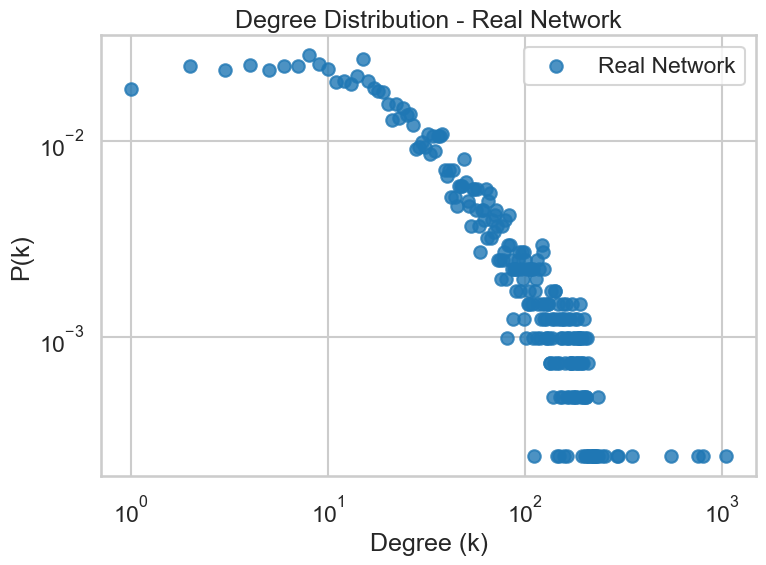

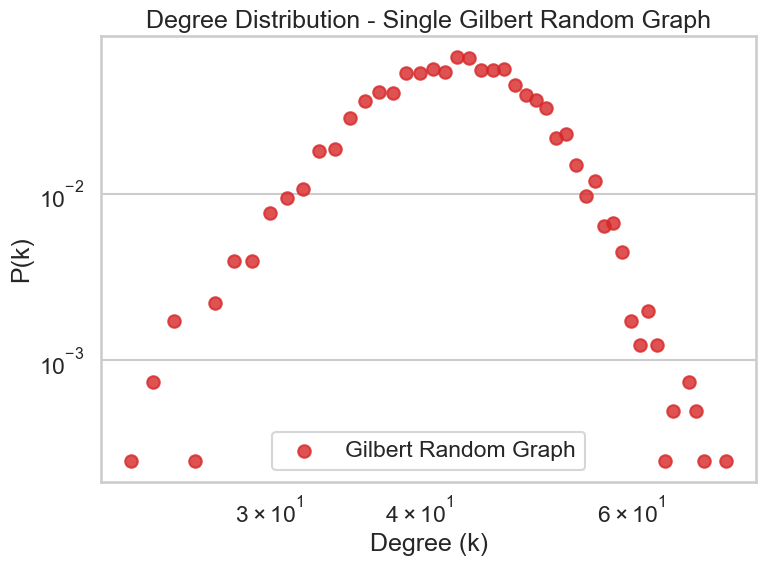

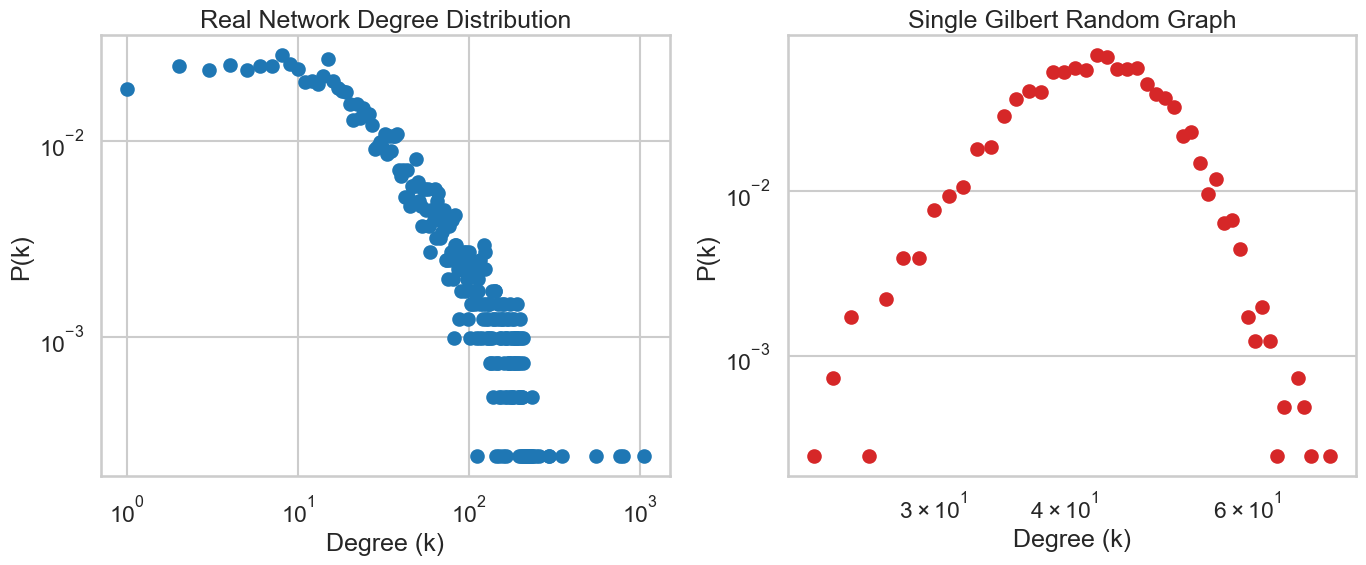

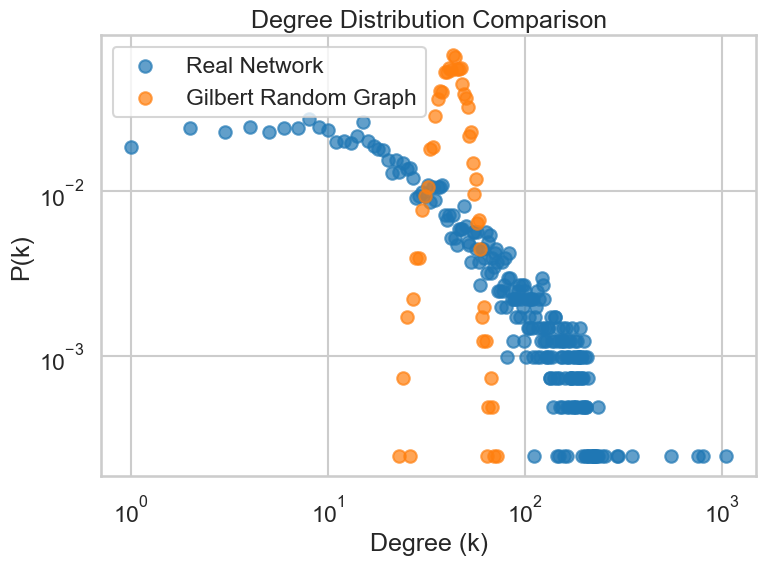

In [7]:
# Plotting both distributions side by side and overlayed for comparison
sns.set_style("whitegrid")
sns.set_context("talk")

# Converting dicts to sorted lists for plotting
def prepare_plot_data(degree_dist):
    k = np.array(sorted(degree_dist.keys()))
    pk = np.array([degree_dist[i] for i in k])
    return k, pk

real_k, real_pk = prepare_plot_data(real_degree_dist)
rand_k, rand_pk = prepare_plot_data(random_degree_dist)


# Real Network Graph
plt.figure(figsize=(8,6))
plt.scatter(real_k, real_pk, label="Real Network", alpha=0.8)
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Distribution - Real Network")
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.legend()
plt.tight_layout()
plt.savefig("part(b)_real_degree_distribution.png", dpi=300)
plt.show()


# Single Gilbert Graph 
plt.figure(figsize=(8,6))
plt.scatter(rand_k, rand_pk, label="Gilbert Random Graph", alpha=0.8, color="#d62728")
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Distribution - Single Gilbert Random Graph")
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.legend()
plt.tight_layout()
plt.savefig("part(b)_random_degree_distribution.png", dpi=300)
plt.show()


# Side-by-side comparison graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(real_k, real_pk, color="#1f77b4")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Real Network Degree Distribution")
axes[0].set_xlabel("Degree (k)")
axes[0].set_ylabel("P(k)")

axes[1].scatter(rand_k, rand_pk, color="#d62728")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Single Gilbert Random Graph")
axes[1].set_xlabel("Degree (k)")
axes[1].set_ylabel("P(k)")

plt.tight_layout()
plt.savefig("part(b)_side_by_side_comparison.png", dpi=300)
plt.show()



# Overlay comparison
plt.figure(figsize=(8, 6))

plt.scatter(real_k, real_pk, label="Real Network", alpha=0.7)
plt.scatter(rand_k, rand_pk, label="Gilbert Random Graph", alpha=0.7)

plt.xscale("log")
plt.yscale("log")

plt.title("Degree Distribution Comparison")
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.legend()
plt.tight_layout()

plt.savefig("part(b)_overlay_comparison.png", dpi=300)
plt.show()


#### Comparison and Reasoning for Real Graph vs One Gilbert Graph

1. The real Facebook network shows a heavy-tailed degree distribution on the log-log plot. 

2. A few nodes have very high degree while most nodes have low degree, indicating the presence of hubs and strong heterogeneity in connectivity.

3. In contrast, the single Gilbert random graph shows a **bell-shaped** distribution centered around the average degree. The degrees are concentrated near the mean, and there are no highly connected hubs. This reflects the random and homogeneous nature of the G(N,p) model.

---

### Compute and plot the average degree distribution over 100 Gilbert graphs

In [8]:
"""
This code block generates multiple instances of the Gilbert random graph 
and computes the average degree distribution across those instances.
"""

num_instances = 100
avg_degree_dist = defaultdict(float)
    
# Generating 100 graphs and accumulate distributions
for i in range(num_instances):
    
    # Generate a new Gilbert random graph
    g = generate_gilbert_random_graph(N, p)
    
    # Compute its degree distribution
    dist = degree_distribution(g)
    
    # Accumulate the distributions
    for k, pk in dist.items():
        avg_degree_dist[k] += pk

# Compute average across all instances
for k in avg_degree_dist:
    avg_degree_dist[k] /= num_instances

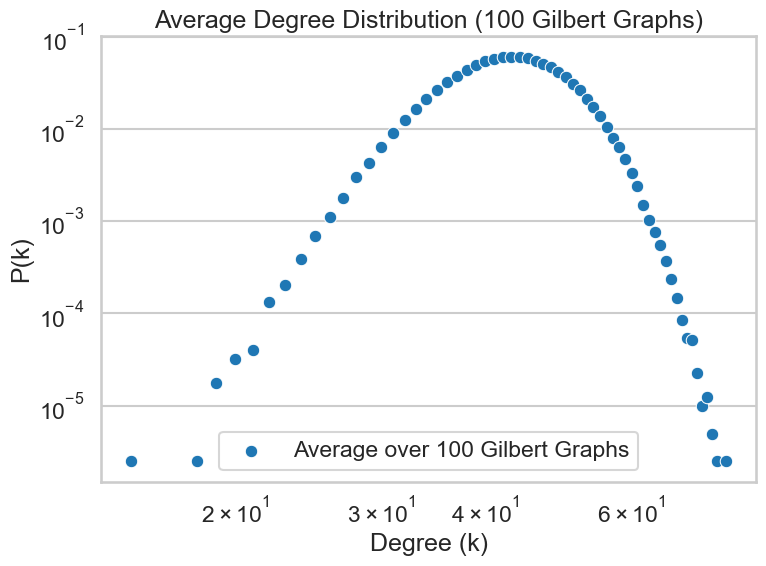

In [9]:
# Plotting the average degree distribution across 100 Gilbert random graphs 

sns.set_style("whitegrid")
sns.set_context("talk")

# Prepare sorted data
avg_k = np.array(sorted(avg_degree_dist.keys()))
avg_pk = np.array([avg_degree_dist[k] for k in avg_k])

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(x=avg_k, y=avg_pk, label="Average over 100 Gilbert Graphs")

plt.xscale("log")
plt.yscale("log")

plt.title("Average Degree Distribution (100 Gilbert Graphs)")
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.legend()

plt.tight_layout()
plt.savefig("part(c)_average_100_gilbert_distribution.png", dpi=300)
plt.show()

### Comparison and Reasoning based on observation of Average over 100 Gilbert Graphs

1. The averaged degree distribution over 100 Gilbert graphs becomes smooth and symmetric around the mean degree. It closely resembles a binomial (approximately Poisson) distribution, with most nodes having degrees near the expected value and very few nodes in the extremes.

2. Unlike the real network, the averaged random graph does not exhibit a heavy tail or highly connected hubs. This further confirms that the real network structure deviates significantly from a purely random model and also confirms that Real-world networks typically do NOT show a Poisson degree distribution.

---

## Comparison Reasoning Summary

1. The real Facebook network shows a heavy-tailed degree distribution, where a few nodes act as hubs with very high degree while most nodes have low degree. This indicates a heterogeneous and non-random structure typical of real-world social networks.

2. In contrast, the Gilbert random graph has a peaked distribution centered around the average degree. The averaged distribution over 100 graphs becomes smooth and resembles a binomial (approximately Poisson) distribution, with no extreme hubs. This demonstrates that the real network structure differs significantly from a purely random graph with the same N and expected number of edges.